In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/Spring_2026/BEE4850/hw/hw02-avinasharavind`


In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using LaTeXStrings # latex formatting for plot strings/

## Problem 1

#### 1.1

In [3]:
chicago = CSV.read("data/chicago.csv", missingstring="NA", DataFrame)

Row,Column1,death,pm10median,pm25median,o3median,so2median,time,tmpd
,Int64,Int64,Float64?,Float64?,Float64,Float64?,Float64,Float64
1,1,130,-7.43354,missing,-19.5923,1.92804,-2556.5,31.5
2,2,150,missing,missing,-19.0386,-0.985563,-2555.5,33.0
3,3,101,-0.826531,missing,-20.2173,-1.89142,-2554.5,33.0
4,4,135,5.56646,missing,-19.6757,6.13934,-2553.5,29.0
5,5,126,missing,missing,-19.2173,2.27846,-2552.5,32.0
6,6,130,6.56646,missing,-17.634,9.85858,-2551.5,40.0
7,7,129,-0.433544,missing,-15.3744,-5.81899,-2550.5,34.5
8,8,109,-5.43354,missing,-12.1705,-5.10794,-2549.5,29.0
9,9,125,-0.571429,missing,-20.0923,0.182237,-2548.5,26.5


In [4]:
describe(chicago, :min, :q25, :median, :q75,:max, :mean, :nmissing)

Row,variable,min,q25,median,q75,max,mean,nmissing
,Symbol,Real,Float64,Float64,Float64,Real,Float64,Int64
1,Column1,1,1279.25,2557.5,3835.75,5114,2557.5,0
2,death,69,105.0,114.0,124.0,411,115.419,0
3,pm10median,-37.3761,-13.1082,-3.53906,8.30292,320.725,-0.14639,251
4,pm25median,-16.4264,-6.58841,-1.32584,5.34377,38.1504,0.243053,4387
5,o3median,-24.7794,-10.2319,-3.32586,4.46821,43.6878,-2.17938,0
6,so2median,-8.2061,-2.68935,-1.21826,0.831593,28.9034,-0.636071,27
7,time,-2556.5,-1278.25,0.0,1278.25,2556.5,0.0,0
8,tmpd,-16.0,35.0,51.0,67.0,92.0,50.1933,0


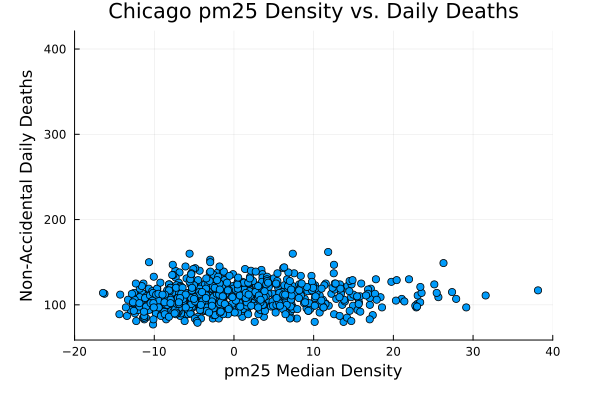

In [5]:
plot(chicago.pm25median, chicago.death, 
    st=:"scatter", xlim=[-20,40], 
    xlabel="pm25 Median Density", 
    ylabel="Non-Accidental Daily Deaths", 
    title="Chicago pm25 Density vs. Daily Deaths",
    legend=false,
    rightmargin=10Plots.mm,
    leftmargin=5Plots.mm,
    bottommargin=5Plots.mm
    )
savefig("figs/1_1_pm25.png")
plot!() #To show plot in notebook

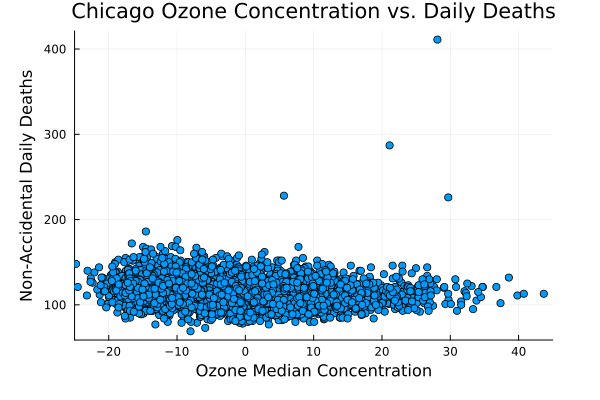

In [6]:
plot(chicago.o3median, chicago.death, 
    st=:"scatter", xlim=[-25,45], 
    xlabel="Ozone Median Concentration", 
    ylabel="Non-Accidental Daily Deaths", 
    title="Chicago Ozone Concentration vs. Daily Deaths",
    legend=false,
    rightmargin=10Plots.mm,
    leftmargin=5Plots.mm,
    bottommargin=5Plots.mm
    )
savefig("figs/1_1_o3.png")
plot!() #To show plot in notebook

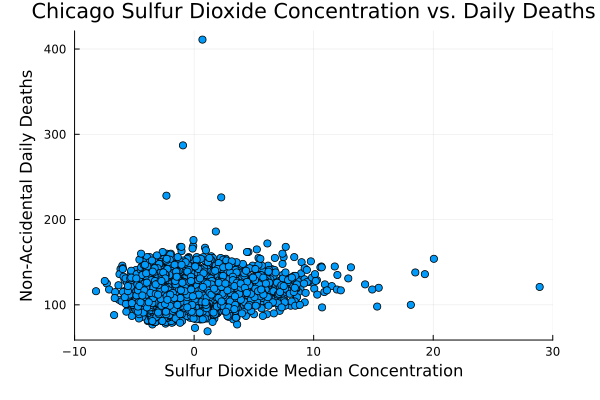

In [7]:
plot(chicago.so2median, chicago.death, 
    st=:"scatter", xlim=[-10,30], 
    xlabel="Sulfur Dioxide Median Concentration", 
    ylabel="Non-Accidental Daily Deaths", 
    title="Chicago Sulfur Dioxide Concentration vs. Daily Deaths",
    legend=false,
    rightmargin=10Plots.mm,
    leftmargin=5Plots.mm,
    bottommargin=5Plots.mm
    )
savefig("figs/1_1_so2.png")
plot!() #To show plot in notebook

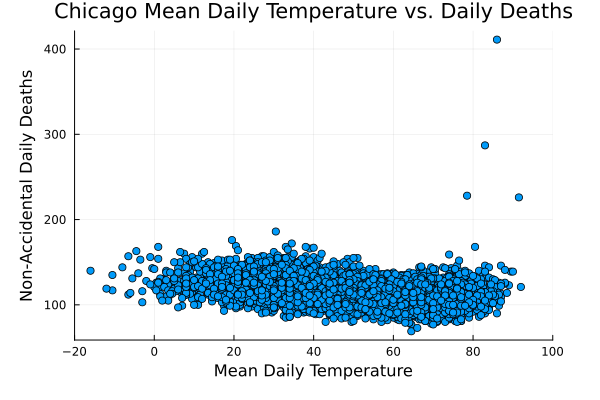

In [8]:
plot(chicago.tmpd, chicago.death, 
    st=:"scatter", xlim=[-20,100], 
    xlabel="Mean Daily Temperature", 
    ylabel="Non-Accidental Daily Deaths", 
    title="Chicago Mean Daily Temperature vs. Daily Deaths",
    legend=false,
    rightmargin=10Plots.mm,
    leftmargin=5Plots.mm,
    bottommargin=5Plots.mm
    )
savefig("figs/1_1_temp.png")
plot!() #To show plot in notebook

#### 1.2

In [9]:
X = chicago.tmpd
Y = chicago.death
beta = zeros(2)
beta[2] = cov(X,Y) / var(X)
beta[1] = mean(Y) - (beta[2]*mean(X))
@show beta
n = length(X)
sigma2 = (Y - [ones(n) X]*beta).^2
s2 = (n/(n-2))*(1/n)*sum(sigma2)
@show s2

beta = [129.95705121476823, -0.28964429615009885]
s2 = 202.31531425938184


202.31531425938184

In [10]:
#MLE Log-Likelihood Estimationm
function  chicago_loglik(theta, deaths, tmpd)
    beta0, beta1, sigma = theta
    mean = beta0 .+ (beta1*tmpd)
    ll = sum(logpdf.(Normal.(mean, sigma), deaths))
    return ll
end

lb = [0.0, -1000.0, 1.0]
ub = [1000.0, 1000.0, 100.0]
theta0 = [500.0, 0.0, 50.0]
optim_out = Optim.optimize(theta -> -chicago_loglik(theta, chicago.death, chicago.tmpd), lb, ub, theta0)
theta_mle = optim_out.minimizer
@show theta_mle
sigma2_mle = (theta_mle[3]^2)*(n/(n-2))
# Numbers should match above cell
# They do to reasonable rounding
# yay

theta_mle = [129.9570512138531, -0.28964429613252857, 14.220977186157482]


202.3153142701072

### 1.3

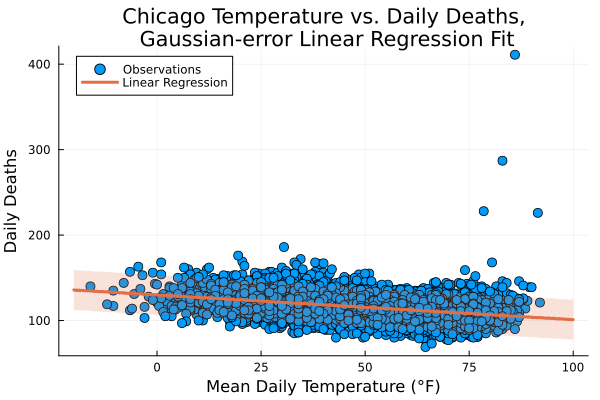

In [11]:
# Simulate 10,000 predictions from data
x = -20:0.1:100 # every 0.1°F
mu = theta_mle[1] .+ theta_mle[2]*x

y_pred = zeros(length(x), 10000)
for i = 1:length(x)
    y_pred[i, :] = rand(Normal(mu[i], theta_mle[3]),10000)
end
y_q = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_pred; dims=2)

p = scatter(
    chicago.tmpd,
    chicago.death,
    xlabel="Mean Daily Temperature (°F)",
    ylabel="Daily Deaths",
    title="Chicago Temperature vs. Daily Deaths,\n Gaussian-error Linear Regression Fit",
    markersize=5,
    label="Observations",
    size = (600, 400))

plot!(x,
    y_q[:, 2],
    ribbon = (y_q[:, 2] - y_q[:, 1], y_q[:, 3] - y_q[:, 2]),
    linewidth=3, 
    fillalpha=0.2, 
    label="Linear Regression",
    size=(600, 400))
    
savefig("figs/1_3_scatter.png")
plot!() #To show plot in notebook

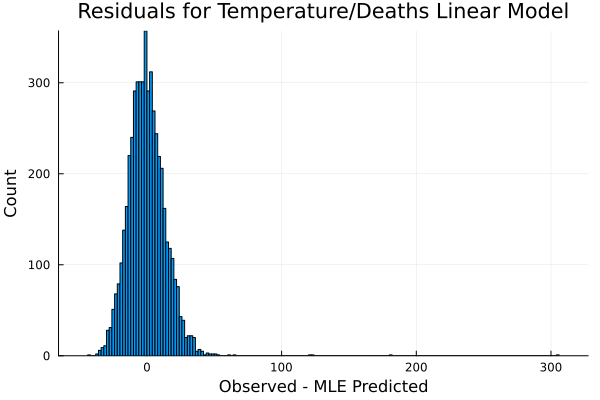

In [12]:
residuals = Y .- (theta_mle[1] .+ (theta_mle[2].*X))
plot(residuals, 
    st=:hist,
    xlabel="Observed - MLE Predicted",
    ylabel="Count",
    title="Residuals for Temperature/Deaths Linear Model",
    legend=false)
savefig("figs/1_3_hist.png")
plot!() #To show plot in notebook

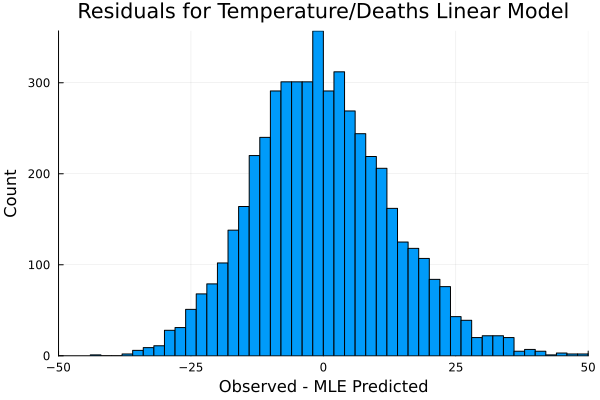

In [13]:
plot(residuals, 
    st=:hist,
    xlabel="Observed - MLE Predicted",
    xlim=(-50,50),
    ylabel="Count",
    title="Residuals for Temperature/Deaths Linear Model",
    legend=false)
savefig("figs/1_3_zoom.png") 
plot!() #To show plot in notebook

## Problem 2

### 2.1

In [14]:
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ",
            ignorerepeated=true, 
            header=["Year", "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December", "Annual"],
            silencewarnings=true, DataFrame)
temp_dat = temp_dat[3:2:nrow(temp_dat), :]

Row,Year,January,February,March,April,May,June,July,August,September,October,November,December,Annual
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?
1,1851,-0.266,-0.467,-0.641,-0.528,-0.222,-0.207,-0.136,-0.148,-0.146,-0.045,-0.108,-0.248,-0.264
2,1852,-0.346,-0.496,-0.567,-0.575,-0.113,-0.077,0.009,-0.149,-0.006,-0.158,-0.275,0.064,-0.224
3,1853,-0.204,-0.399,-0.273,-0.401,-0.27,-0.124,-0.072,-0.04,-0.266,-0.373,-0.401,-0.326,-0.262
4,1854,-0.403,-0.392,-0.247,-0.327,-0.277,-0.302,-0.162,-0.233,-0.216,-0.099,-0.412,-0.454,-0.294
5,1855,-0.17,-0.313,-0.345,-0.211,-0.368,-0.333,-0.315,-0.202,-0.259,-0.2,-0.374,-0.408,-0.291
6,1856,-0.083,-0.347,-0.371,-0.314,-0.293,-0.225,-0.223,-0.249,-0.402,-0.446,-0.561,-0.423,-0.328
7,1857,-0.494,-0.442,-0.488,-0.675,-0.654,-0.291,-0.404,-0.356,-0.368,-0.467,-0.662,-0.289,-0.466
8,1858,-0.336,-0.488,-0.566,-0.43,-0.523,-0.36,-0.341,-0.288,-0.28,-0.292,-0.404,-0.455,-0.397
9,1859,-0.405,-0.351,-0.322,-0.189,-0.17,-0.24,-0.29,-0.266,-0.401,-0.247,-0.31,-0.311,-0.292


In [15]:
temp_dat[:, "DJF_Mean"] = zeros(nrow(temp_dat))
temp_dat[:, "Frozen"] = zeros(nrow(temp_dat))

for i = 2:nrow(temp_dat)
    temp_dat[i, "DJF_Mean"] = mean([temp_dat[i-1, "December"], temp_dat[i, "January"], temp_dat[i, "February"]])
    if temp_dat.Year[i] in [1856, 1875, 1884, 1904, 1912, 1934, 1961, 1979, 2015]
        temp_dat[i, "Frozen"] = 1
    else
        temp_dat[i, "Frozen"] = 0
    end
end

In [16]:
function invlogit(x)
   return exp(x) / (1+exp(x))
end

function logistic_loglik(theta, y, x)
    beta_0, beta_1 = theta
    p = invlogit.(beta_0 .+ (beta_1*x))
    ll = sum(logpdf.(Bernoulli.(p), y))
    return ll
end

lb = [-5.0, -5.0]
ub = [5.0, 5.0]
p0 = [0.0, 0.0]
optim_out = Optim.optimize(p -> -logistic_loglik(p, temp_dat.Frozen .> 0, temp_dat.DJF_Mean), lb, ub, p0)
mle = optim_out.minimizer

2-element Vector{Float64}:
 -3.0178514758810584
 -0.729619157916247

In [17]:
exp(mle[1]), exp(mle[2])

(0.04890618167442439, 0.4820925562668116)

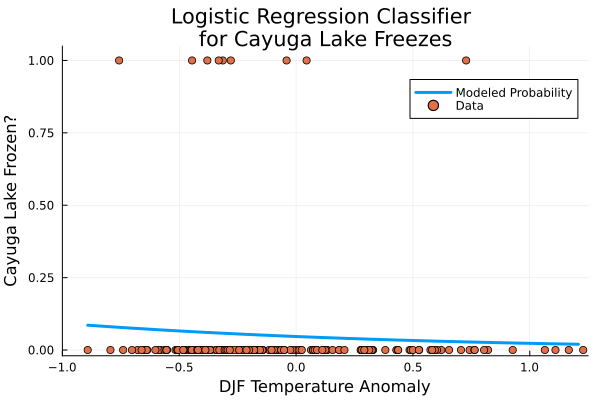

In [18]:
x_pred = minimum(temp_dat.DJF_Mean):0.1:maximum(temp_dat.DJF_Mean)
p_pred = invlogit.(mle[1] .+ mle[2] * x_pred)
plot(x_pred, p_pred, linewidth=3, 
    label="Modeled Probability", 
    xlabel="DJF Temperature Anomaly", 
    ylabel="Cayuga Lake Frozen?", 
    legend_position=(0.75,0.85),
    title="Logistic Regression Classifier \nfor Cayuga Lake Freezes",
    ylim=(-0.02,1.05), xlim=(-1, 1.25), size=(600, 400))
scatter!(temp_dat.DJF_Mean, temp_dat.Frozen .> 0, label="Data")
savefig("figs/2_1.png")
plot!() #To show plot in notebook

### 2.2

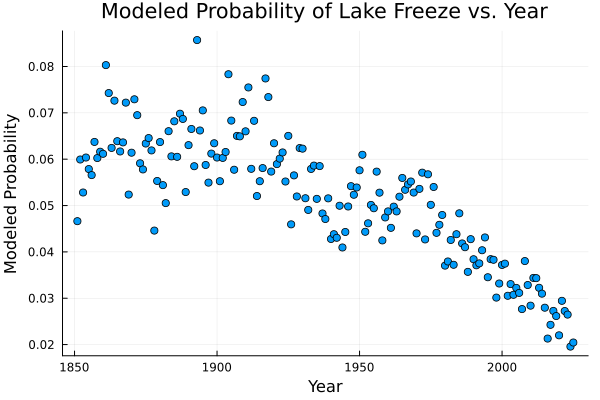

In [19]:
p_historical = invlogit.(mle[1] .+ mle[2]*temp_dat.DJF_Mean)
scatter(1851:2025, p_historical, legend=false,
        xlabel="Year", ylabel="Modeled Probability",
        title="Modeled Probability of Lake Freeze vs. Year")
savefig("figs/2_2.png")
plot!() #To show plot in notebook

### 2.3

In [20]:
(log(.01/.99) - mle[1])/mle[2]

2.1617694068753965

## Problem 3

### 3.1

In [21]:
sals = CSV.read("data/salamanders.csv", delim=";", DataFrame)

Row,SITE,SALAMAN,PCTCOVER,FORESTAGE
,Int64,Int64,Int64,Int64
1,1,13,85,316
2,2,11,86,88
3,3,11,90,548
4,4,9,88,64
5,5,8,89,43
6,6,7,83,368
7,7,6,83,200
8,8,6,91,71
9,9,5,88,42


In [22]:
stdz(x) = (x .- mean(x)) / std(x)
function poisson_loglik(theta, grdcover, salcount)
    b0, b1 = theta
    lambda = exp.(b0 .+ (b1*grdcover))
    ll = sum(logpdf.(Poisson.(lambda), salcount))
    return ll
end

lb = [-100., -100.]
ub = [100., 100.]
th0 = [0., 0.]

optim_out = optimize(theta -> -poisson_loglik(theta, stdz(sals.PCTCOVER), sals.SALAMAN), lb, ub, th0)
mle = optim_out.minimizer

2-element Vector{Float64}:
 0.4295112911917795
 1.1595061319045692

### 3.2

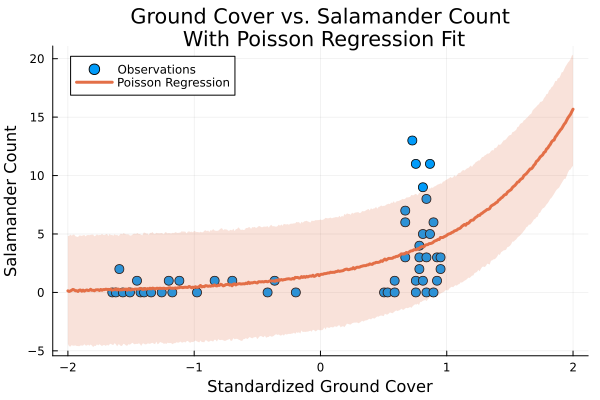

In [23]:
x_cover = -2:0.01:2
mu = exp.(mle[1] .+ (mle[2]*x_cover))
sigma2 = (1/nrow(sals))*sum((sals.SALAMAN - exp.(mle[1] .+ (mle[2]*stdz(sals.PCTCOVER)))).^2)
sigma = sqrt(sigma2)

y_pred = zeros(length(x_cover), 10000)
for i = 1:length(x_cover)
    y_pred[i, :] = rand(Normal(mu[i], sigma),10000)
end
y_q = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_pred; dims=2)

p = scatter(
    stdz(sals.PCTCOVER),
    sals.SALAMAN,
    xlabel="Standardized Ground Cover",
    ylabel="Salamander Count",
    title="Ground Cover vs. Salamander Count\n With Poisson Regression Fit",
    markersize=5,
    label="Observations",
    size = (600, 400))

plot!(x_cover,
    y_q[:, 2],
    ribbon = (y_q[:, 2] - y_q[:, 1], y_q[:, 3] - y_q[:, 2]),
    linewidth=3, 
    fillalpha=0.2, 
    label="Poisson Regression",
    size=(600, 400))
savefig("figs/3_2.png")
plot!() #To show plot in notebook

### 3.3

In [24]:
mse = sum((sals.SALAMAN - exp.(mle[1] .+ (mle[2]*stdz(sals.PCTCOVER)))).^2)/nrow(sals)

8.205326223735485

In [25]:
function poisson_loglik(theta, grdcover, forestage, salcount)
    b0, b1, b2 = theta
    lambda = exp.(b0 .+ (b1*grdcover) .+ (b2*forestage))
    ll = sum(logpdf.(Poisson.(lambda), salcount))
    return ll
end

lb = [-100., -100., -100.]
ub = [100., 100., 100.]
th0 = [0., 0., 0.]

optim_out = optimize(theta -> -poisson_loglik(theta, stdz(sals.PCTCOVER), stdz(sals.FORESTAGE), sals.SALAMAN), lb, ub, th0)
mle = optim_out.minimizer

3-element Vector{Float64}:
  0.4293187207669783
  1.1624676136697254
 -0.004084430274221949

In [26]:
mse = sum((sals.SALAMAN - exp.(mle[1] .+ (mle[2]*stdz(sals.PCTCOVER) .+ (mle[3]*stdz(sals.FORESTAGE))))).^2)/nrow(sals)

8.204880991254662

## Problem 4

### 4.1

In [27]:
hurricanes = CSV.read("data/Hurricanes.csv", DataFrame)

Row,name,year,deaths,category,min_pressure,damage_norm,female,femininity
,String15,Int64,Int64,Int64,Int64,Int64,Int64,Float64
1,Easy,1950,2,3,960,1590,1,6.77778
2,King,1950,4,3,955,5350,0,1.38889
3,Able,1952,3,1,985,150,0,3.83333
4,Barbara,1953,1,1,987,58,1,9.83333
5,Florence,1953,0,1,985,15,1,8.33333
6,Carol,1954,60,3,960,19321,1,8.11111
7,Edna,1954,20,3,954,3230,1,8.55556
8,Hazel,1954,20,4,938,24260,1,9.44444
9,Connie,1955,0,3,962,2030,1,8.5


In [28]:
function poisson_loglik(theta, female, mslp, deaths)
    b0, b1, b2 = theta
    lambda = exp.(b0 .+ (b1*female) .+ (b2*mslp))
    ll = sum(logpdf.(Poisson.(lambda), deaths))
    return ll
end

lb = [-100., -100., -100.]
ub = [100., 100., 100.]
th0 = [0., 0., 0.]

optim_out = optimize(theta -> -poisson_loglik(theta, hurricanes.female, stdz(hurricanes.min_pressure), hurricanes.deaths), lb, ub, th0)
mle = optim_out.minimizer

3-element Vector{Float64}:
  2.414667236678301
  0.47211173926789884
 -0.7195324699539148

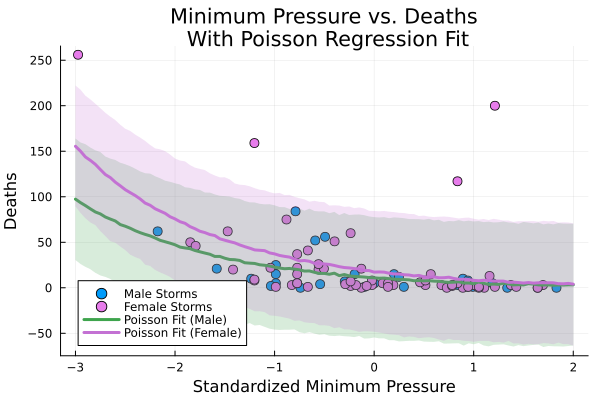

In [29]:
x_gen = -3:0.05:2
gen_male = exp.(mle[1] .+ (mle[2]*0) .+ (mle[3]*x_gen))
gen_female = exp.(mle[1] .+ (mle[2]*1) .+ (mle[3]*x_gen))
obs_male = hurricanes[hurricanes.female .== 0, :]
obs_female = hurricanes[hurricanes.female .== 1, :]

y_male = zeros(length(x_gen), 10000)
y_female = zeros(length(x_gen), 10000)
for i = 1:length(x_gen)
    y_male[i, :] = rand(Normal(gen_male[i], sqrt(var(hurricanes.deaths))),10000)
    y_female[i, :] = rand(Normal(gen_female[i], sqrt(var(hurricanes.deaths))),10000)
end
y_q_m = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_male; dims=2)
y_q_f = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_female; dims=2)

p = scatter(
    stdz(obs_male.min_pressure),
    obs_male.deaths,
    xlabel="Standardized Minimum Pressure",
    ylabel="Deaths",
    title="Minimum Pressure vs. Deaths\n With Poisson Regression Fit",
    markersize=5,
    label="Male Storms",
    size = (600, 400))

scatter!(
    stdz(obs_female.min_pressure),
    obs_female.deaths,
    color="#e77ceb",
    markersize=5,
    label="Female Storms",
    size = (600, 400))

plot!(x_gen,
    y_q_m[:, 2],
    ribbon = (y_q_m[:, 2] - y_q_m[:, 1], y_q_m[:, 3] - y_q_m[:, 2]),
    linewidth=3, 
    fillalpha=0.2, 
    label="Poisson Fit (Male)",
    size=(600, 400))

plot!(x_gen,
    y_q_f[:, 2],
    ribbon = (y_q_f[:, 2] - y_q_f[:, 1], y_q_f[:, 3] - y_q_f[:, 2]),
    linewidth=3, 
    fillalpha=0.2, 
    label="Poisson Fit (Female)",
    size=(600, 400))


savefig("figs/4_2.png")

plot!() #To show plot in notebook

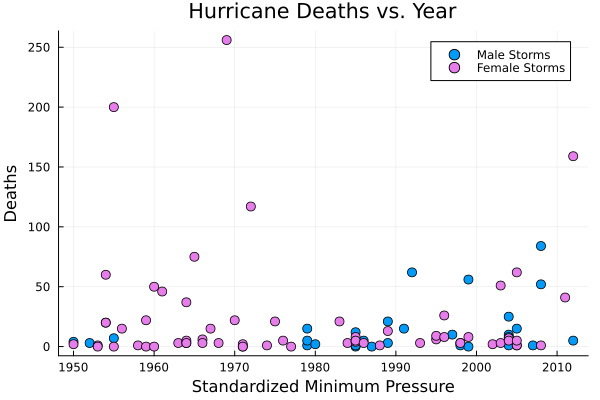

In [30]:
scatter(
    obs_male.year,
    obs_male.deaths,
    markersize=5,
    label="Male Storms",
    xlabel="Standardized Minimum Pressure",
    ylabel="Deaths",
    title="Hurricane Deaths vs. Year",
    size = (600, 400))

scatter!(
    obs_female.year,
    obs_female.deaths,
    markersize=5,
    label="Female Storms",
    color="#e77ceb",
    )

savefig("figs/4_4.png")

plot!() #To show plot in notebook

In [31]:
nrow(obs_female), nrow(obs_male)

(62, 30)